In [1]:
!pip install chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta

In [2]:
# 로컬 파일 저장, 유사도 기반 문장 분류, 문장 클러스터링
import chromadb
from chromadb import PersistentClient    # DB 접속자 역할
from sentence_transformers import SentenceTransformer

client = chromadb.PersistentClient(path='./chroma_db')
collection = client.get_or_create_collection(name='simple_texts', metadata={'hnsw:space': 'l2'})    # 알고리즘 이름:유클리디안 거리

texts = [
    '사과는 과일이다',
    '파이썬은 프로그래밍 언어다',
    '해는 동쪽에서 뜬다',
    '나는 망고를 좋아해요'
]

ids = [str(i) for i in range(len(texts))]
print(ids)

['0', '1', '2', '3']


In [3]:
# 임베딩 모델 로딩
model = SentenceTransformer('all-MiniLM-L6-v2')
print("현재 모델 임베딩 차원 수 : ", model.get_sentence_embedding_dimension())
print(model)

embeddings = model.encode(texts).tolist()
print(embeddings[:3])
print(model.encode(texts).shape)    # (4, 384)

# 벡터DB에 저장
collection.add(documents=texts, ids=ids, embeddings=embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

현재 모델 임베딩 차원 수 :  384
SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
[[-0.03665332868695259, 0.08160005509853363, 0.01821831241250038, -0.009533345699310303, -0.04872555285692215, -0.04989885538816452, 0.1210956946015358, -0.0011590335052460432, -0.007949450984597206, 0.002437886083498597, 0.1283920556306839, -0.02842547930777073, 0.07470134645700455, -0.05304323509335518, 0.1280648559331894, -0.05502286180853844, -0.025285780429840088, -0.012332351878285408, -0.10482940077781677, -0.01936398260295391, 0.018946435302495956, 0.023653116077184677, -0.005153242964297533, 0.04872948303818703, -0.07554055005311

In [4]:
# 저장된 벡터 출력
record = collection.get(ids=['0'], include=['embeddings', 'documents'])
print(f"첫번째 문서 : {record['documents'][0]}")
print(f"첫번째 문서의 임베딩 벡터값 : {record['embeddings'][0][:10]}")

# 유사 문장 검색
query = '파이썬이 뭐냐'
query_vector = model.encode([query]).tolist()
print(model.encode(query).shape, model.encode([query]).shape)    # model.encode(query) -> 1차원 벡터, ([query]) -> 2차원 벡터

result = collection.query(query_embeddings=query_vector, n_results=2,
                          include=["documents","distances"])   # 검색 결과에 포함시킬 항목을 지정
print('검색 결과 :')
for doc, dist in zip(result['documents'][0], result['distances'][0]):
  print(f"문장 : {doc}( 유사도 거리 : {dist:.4f})")

첫번째 문서 : 사과는 과일이다
첫번째 문서의 임베딩 벡터값 : [-0.03665333  0.08160006  0.01821831 -0.00953335 -0.04872555 -0.04989886
  0.12109569 -0.00115903 -0.00794945  0.00243789]
(384,) (1, 384)
검색 결과 :
문장 : 파이썬은 프로그래밍 언어다( 유사도 거리 : 0.4987)
문장 : 나는 망고를 좋아해요( 유사도 거리 : 0.7733)


In [5]:
# 유사도 기반 문장 분류기 작성
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np

texts2 = [
    "나는 과일을 즐겨 먹는다",
    "바나나는 내가 좋아하는 과일이야",
    "파이썬은 훌륭한 프로그래밍 언어야",
    "나는 가끔 파이썬을 이용해 코딩 하고 있어",
    "사과와 바나나 둘 다 맛이 좋아",
    "파이썬으로 코딩하면 이해가 잘돼",
    "나는 망고 스무디를 즐겨 마셔",
    "과일은 건강한 간식이야",
    "나는 열대 과일을 특히 좋아해"
]

mymodel = SentenceTransformer('all-MiniLM-L6-v2')
myembeddings = model.encode(texts2)
# print(myembeddings[:2])

# 클러스터링
n_clusters = 3    # cluster 개수, k값
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans_model.fit_predict(myembeddings)

print(labels)    # 9개 문장을 3개로 나눔

for idx, (text, label) in enumerate(zip(texts2, labels)):
  print(f"[군집 {label}] : {text}")

[1 2 0 0 1 0 1 1 1]
[군집 1] : 나는 과일을 즐겨 먹는다
[군집 2] : 바나나는 내가 좋아하는 과일이야
[군집 0] : 파이썬은 훌륭한 프로그래밍 언어야
[군집 0] : 나는 가끔 파이썬을 이용해 코딩 하고 있어
[군집 1] : 사과와 바나나 둘 다 맛이 좋아
[군집 0] : 파이썬으로 코딩하면 이해가 잘돼
[군집 1] : 나는 망고 스무디를 즐겨 마셔
[군집 1] : 과일은 건강한 간식이야
[군집 1] : 나는 열대 과일을 특히 좋아해


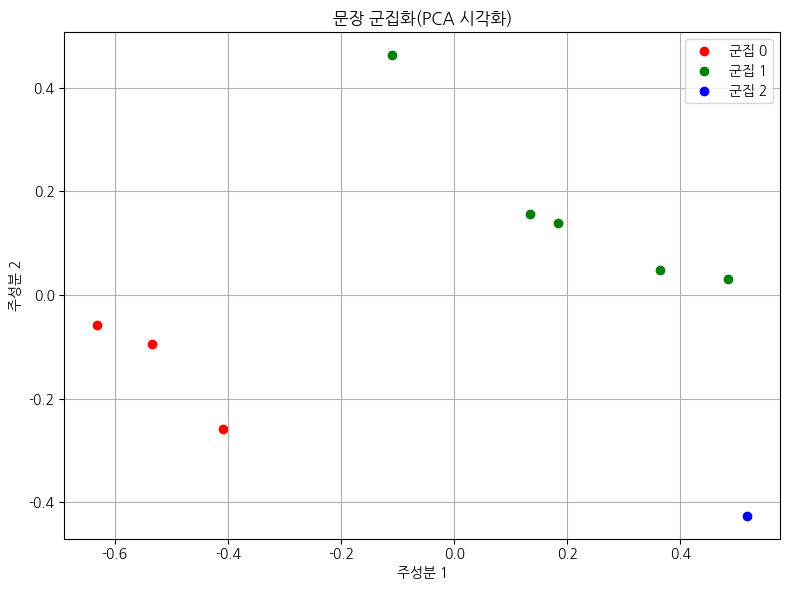

In [9]:
# 군집 결과 시각화
# - 384차원을 시각화할 수 없다. 그래서 2차원으로 차원축소(PCA)
# !pip install koreanize-matplotlib

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import koreanize_matplotlib
import numpy as np

pca = PCA(n_components=2)
reduced = pca.fit_transform(myembeddings)
# print(reduced)

plt.figure(figsize=(8,6))
colors=['red','green','blue','orange','purple']
for i in range(n_clusters):
  cluster_points = reduced[labels == i]
  plt.scatter(cluster_points[:,0], cluster_points[:,1], c=colors[i % len(colors)], label=f'군집 {i}')
plt.title('문장 군집화(PCA 시각화)')
plt.xlabel('주성분 1')
plt.ylabel('주성분 2')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

In [11]:
# 클러스터별 대표 문장 추출
from sklearn.metrics import pairwise_distances_argmin_min
# 두 벡터 집합 간의 가장 가까운 쌍(인덱스와 거리)
print("클러스터별 대표 문장 : 중심에 가장 가까움")
for i in range(n_clusters):
  cluster_indices = np.where(labels == i)[0]
  cluster_embeddings = myembeddings[cluster_indices]    # i번 클러스터에 속한 문장들의 벡터 모음

  center = kmeans_model.cluster_centers_[i].reshape(1, -1)    # i번 클러스터의 중심
  closest_idx, _ = pairwise_distances_argmin_min(center, cluster_embeddings)

  closest_text = texts2[cluster_indices[closest_idx[0]]]    # 클러스터 중심에 가장 가까운 문장을 texts
  print(f"[Cluster{i}] {closest_text}")

print('\n클러스터별 전체 문장')
for i in range(n_clusters):
  print(f"\n[Cluster{i}]")
  for idx, (text, label) in enumerate(zip(texts2, labels)):
    if label == i:
      print(f" - {text}")

클러스터별 대표 문장 : 중심에 가장 가까움
[Cluster0] 파이썬으로 코딩하면 이해가 잘돼
[Cluster1] 나는 열대 과일을 특히 좋아해
[Cluster2] 바나나는 내가 좋아하는 과일이야

클러스터별 전체 문장

[Cluster0]
 - 파이썬은 훌륭한 프로그래밍 언어야
 - 나는 가끔 파이썬을 이용해 코딩 하고 있어
 - 파이썬으로 코딩하면 이해가 잘돼

[Cluster1]
 - 나는 과일을 즐겨 먹는다
 - 사과와 바나나 둘 다 맛이 좋아
 - 나는 망고 스무디를 즐겨 마셔
 - 과일은 건강한 간식이야
 - 나는 열대 과일을 특히 좋아해

[Cluster2]
 - 바나나는 내가 좋아하는 과일이야
